In [1]:
if haskey(ENV, "COLAB_GPU")
    import Pkg
    Pkg.add("SpecialFunctions")
    Pkg.add("CairoMakie")
end

using LinearAlgebra: norm
import CairoMakie as cm
import CairoMakie.:(..)
using SpecialFunctions
fact(x) = exp(lfactorial(x))

function vf_func(complex_func)
    function f(point)
        x, y = point
        z = complex(x, y)
        w = complex_func(z)
        w = isnan(w) ? zero(w) : w
        cm.Point2f(real(w), -imag(w))
    end
    f
end

function streamplot_complex_func(complex_func, x=-1..1, y=-1..1;
        size=(500, 500), colormap=:rainbow, color=log∘norm, title="", titlesize=20)
    fig = cm.Figure(; size)
    ax = cm.Axis(fig[1,1]; title, titlesize)
    cm.streamplot!(ax, vf_func(complex_func), x, y; colormap, color)
    fig
end

streamplot_complex_func (generic function with 3 methods)

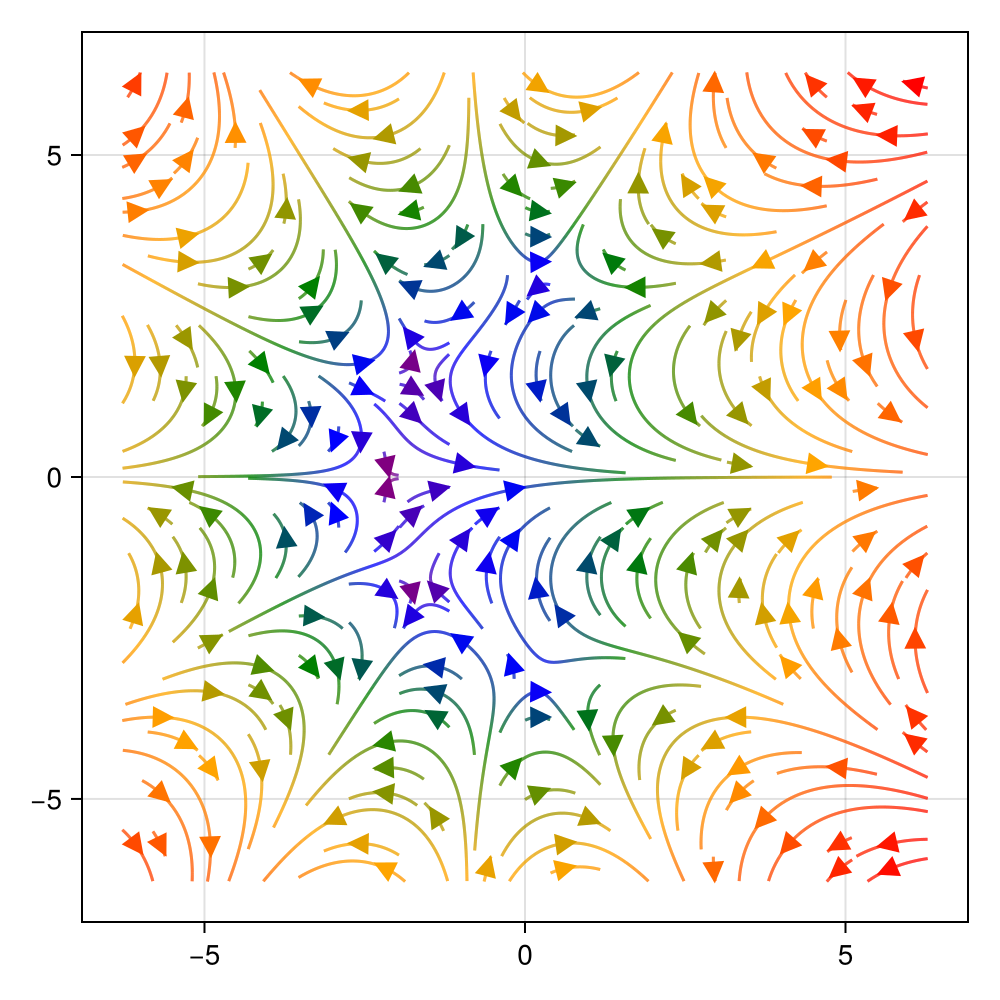

In [2]:
F(z) = sum(k -> z^k / fact(k), 0:5)
streamplot_complex_func(F, -2pi..2pi, -2pi..2pi)

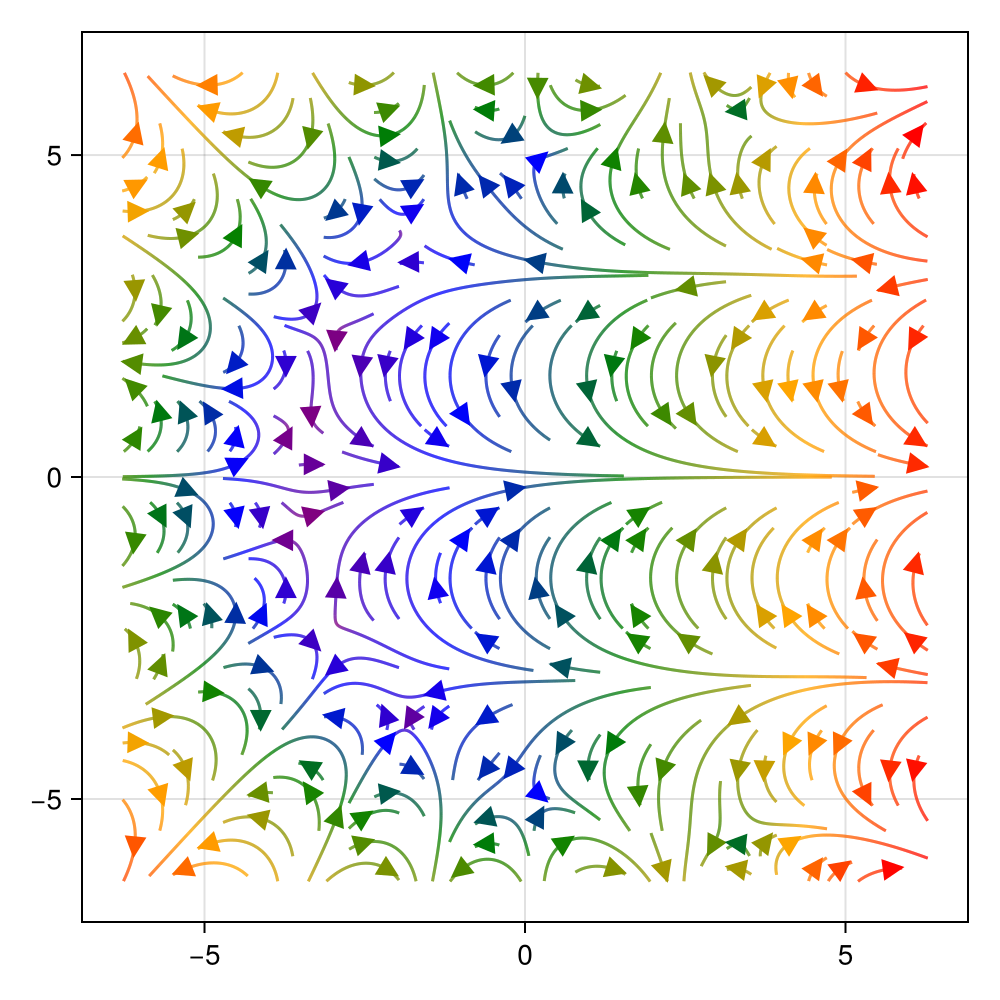

In [3]:
F(z) = sum(k -> z^k / fact(k), 0:10)
streamplot_complex_func(F, -2pi..2pi, -2pi..2pi)

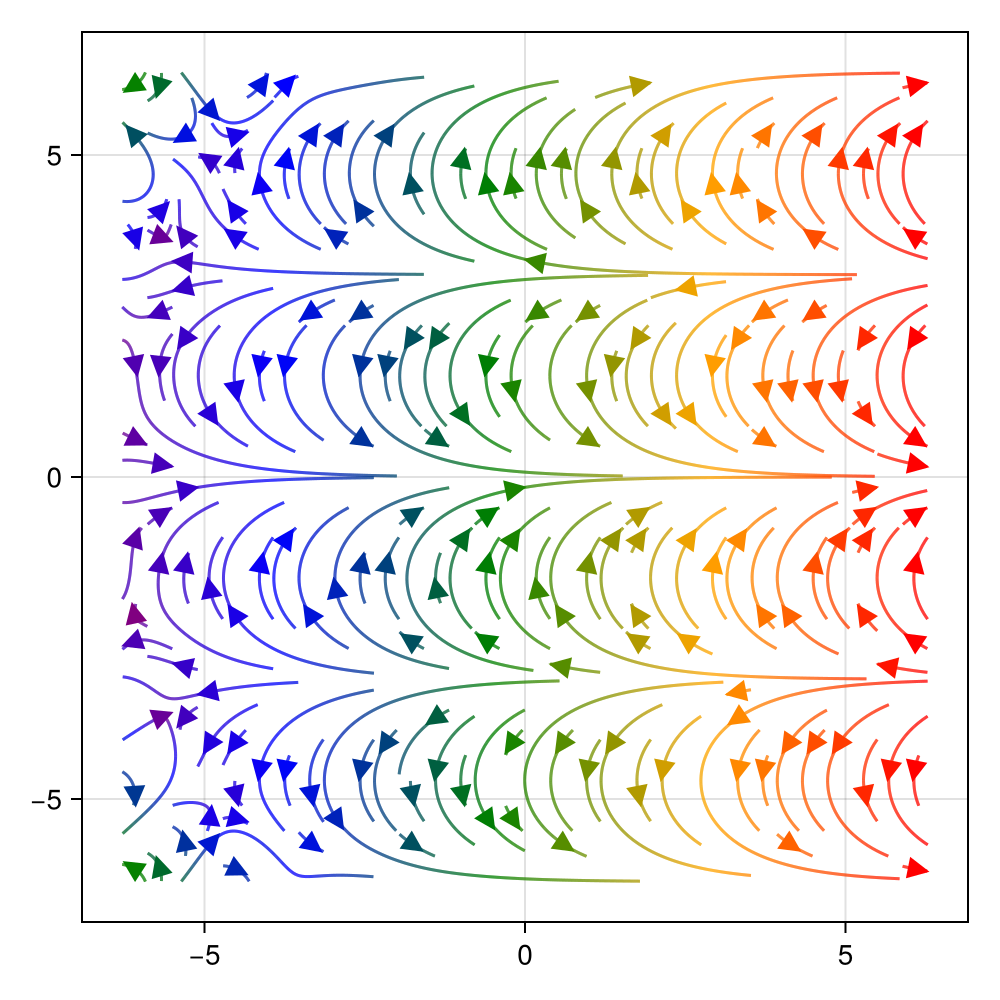

In [4]:
F(z) = sum(k -> z^k / fact(k), 0:20)
streamplot_complex_func(F, -2pi..2pi, -2pi..2pi)

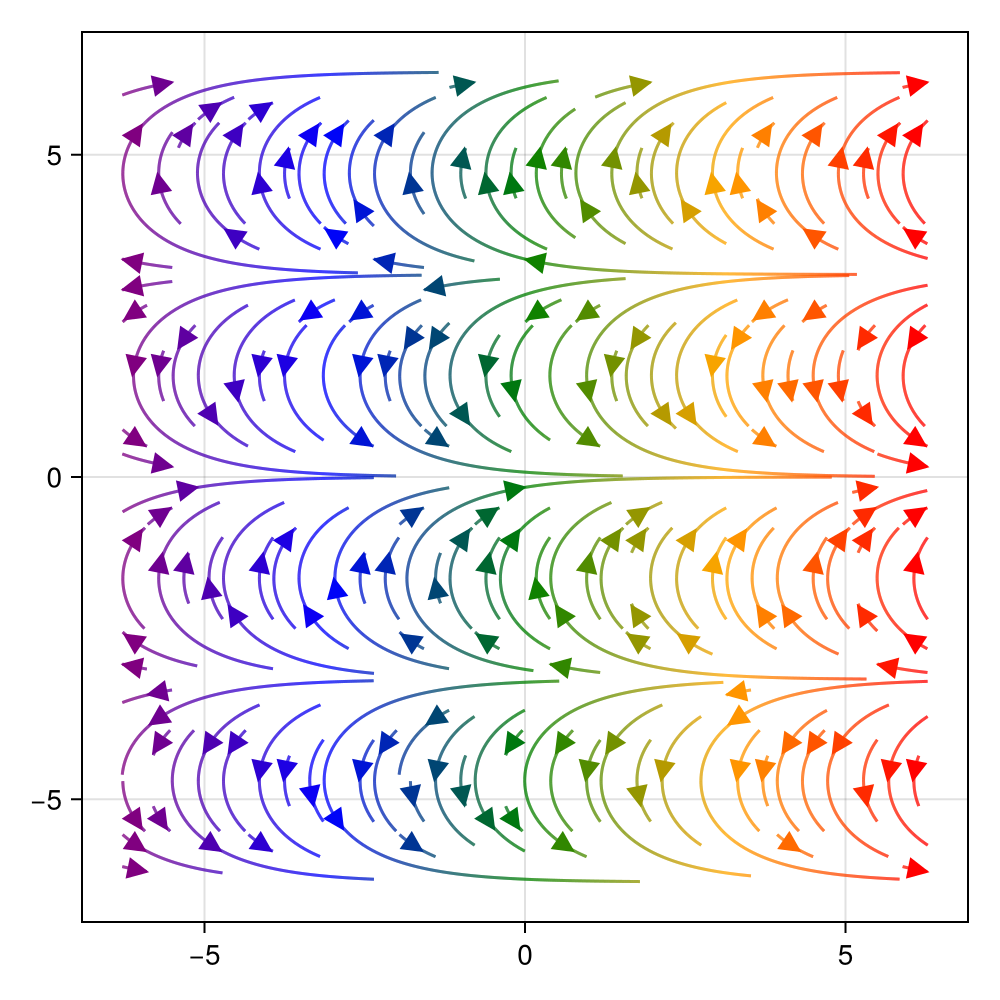

In [5]:
F(z) = exp(z)
streamplot_complex_func(F, -2pi..2pi, -2pi..2pi)